# Завдання 1

У вас є текстовий файл, який містить інформацію про місячні заробітні плати розробників у вашій компанії. Кожен рядок у файлі містить прізвище розробника та його заробітну плату, які розділені комою без пробілів.

Наприклад:

Alex Korp,3000
Nikita Borisenko,2000
Sitarama Raju,1000

Ваше завдання - розробити функцію total_salary(path), яка аналізує цей файл і повертає загальну та середню суму заробітної плати всіх розробників.



Вимоги до завдання:

Функція total_salary(path) має приймати один аргумент - шлях до текстового файлу (path).
Файл містить дані про заробітні плати розробників, розділені комами. Кожен рядок вказує на одного розробника.
Функція повинна аналізувати файл, обчислювати загальну та середню суму заробітної плати.
Результатом роботи функції є кортеж із двох чисел: загальної суми зарплат і середньої заробітної плати.


Рекомендації для виконання:

Використовуйте менеджер контексту with для читання файлів.
Пам'ятайте про встановлення кодування при відкриті файлів
Для розділення даних у кожному рядку можна застосувати метод split(',').
Обрахуйте загальну суму заробітної плати, а потім розділіть її на кількість розробників, щоб отримати середню зарплату.
Опрацьовуйте можливі винятки при роботі з файлами, такі як відсутність файлу.


Критерії оцінювання:

Функція повинна точно обчислювати загальну та середню суми.
Повинна бути обробка випадків, коли файл відсутній або пошкоджений.
Код має бути чистим, добре структурованим і зрозумілим.


Приклад використання функції:

total, average = total_salary("path/to/salary_file.txt")
print(f"Загальна сума заробітної плати: {total}, Середня заробітна плата: {average}")

Очікуваний результат:

Загальна сума заробітної плати: 6000, Середня заробітна плата: 2000

In [ ]:
import pathlib

def total_salary(path: str) -> tuple[int, int]:
    """
    Calculate total sum and average salary from a file.
    :param path: Path to the salary file.
    :return: A tuple containing total sum and average salary.
    """
    path = pathlib.Path(path)

    try:
        with path.open("r", encoding="utf-8") as fin:
            salaries = [float(line.split(",")[1].strip()) for line in fin.readlines() if len(line.split(",")) == 2]
    except FileNotFoundError:
        print(f"File not found: {path}")
        return 0, 0
    if not salaries:
        return 0, 0
    return sum(salaries), sum(salaries)/len(salaries)

total, average = total_salary("salary_file.txt")
print(f"Загальна сума заробітної плати: {total:.0f}, Середня заробітна плата: {average:.0f}")


Загальна сума заробітної плати: 6000, Середня заробітна плата: 2000


# Завдання 2

У вас є текстовий файл, який містить інформацію про котів. Кожен рядок файлу містить унікальний ідентифікатор кота, його ім'я та вік, розділені комою. Наприклад:

60b90c1c13067a15887e1ae1,Tayson,3
60b90c2413067a15887e1ae2,Vika,1
60b90c2e13067a15887e1ae3,Barsik,2
60b90c3b13067a15887e1ae4,Simon,12
60b90c4613067a15887e1ae5,Tessi,5

Ваше завдання - розробити функцію get_cats_info(path), яка читає цей файл та повертає список словників з інформацією про кожного кота.



Вимоги до завдання:

Функція get_cats_info(path) має приймати один аргумент - шлях до текстового файлу (path).
Файл містить дані про котів, де кожен запис містить унікальний ідентифікатор, ім'я кота та його вік.
Функція має повертати список словників, де кожен словник містить інформацію про одного кота.


Рекомендації для виконання:

Використовуйте with для безпечного читання файлу.
Пам'ятайте про встановлення кодування при відкриті файлів
Для кожного рядка в файлі використовуйте split(',') для отримання ідентифікатора, імені та віку кота.
Утворіть словник з ключами "id", "name", "age" для кожного кота та додайте його до списку, який буде повернуто.
Опрацьовуйте можливі винятки, пов'язані з читанням файлу.


Критерії оцінювання:

Функція має точно обробляти дані та повертати правильний список словників.
Повинна бути належна обробка винятків і помилок.
Код має бути чистим, добре структурованим і зрозумілим.


Приклад використання функції:

cats_info = get_cats_info("path/to/cats_file.txt")
print(cats_info)



Очікуваний результат:

[
    {"id": "60b90c1c13067a15887e1ae1", "name": "Tayson", "age": "3"},
    {"id": "60b90c2413067a15887e1ae2", "name": "Vika", "age": "1"},
    {"id": "60b90c2e13067a15887e1ae3", "name": "Barsik", "age": "2"},
    {"id": "60b90c3b13067a15887e1ae4", "name": "Simon", "age": "12"},
    {"id": "60b90c4613067a15887e1ae5", "name": "Tessi", "age": "5"},
]

In [ ]:
import pathlib

def get_cats_info(path: str) -> list[dict[str, str | int]]:
    """
    Fetch cats information from a file.
    :param path: Path to the cats info file.
    :return: A list of dictionaries containing cats' information.
    """
    path = pathlib.Path(path)
    try:
        with path.open("r", encoding="utf-8") as fin:
            cats = []
            for line in fin.readlines():
                if len(line.strip().split(",")) != 3:
                    raise ValueError("Invalid line format, expected 3 values separated by commas.")
                id, name, age = line.strip().split(",")
                cats.append({"id": id, "name": name, "age": int(age)})
    except FileNotFoundError:
        print(f"File not found: {path}")
        return []
    return cats

cats_info = get_cats_info("cats_file.txt")
print(cats_info)

[{'id': '60b90c1c13067a15887e1ae1', 'name': 'Tayson', 'age': 3}, {'id': '60b90c2413067a15887e1ae2', 'name': 'Vika', 'age': 1}, {'id': '60b90c2e13067a15887e1ae3', 'name': 'Barsik', 'age': 2}, {'id': '60b90c3b13067a15887e1ae4', 'name': 'Simon', 'age': 12}, {'id': '60b90c4613067a15887e1ae5', 'name': 'Tessi', 'age': 5}]


# Завдання 3

Розробіть скрипт, який приймає шлях до директорії в якості аргументу командного рядка і візуалізує структуру цієї директорії, виводячи імена всіх піддиректорій та файлів. Для кращого візуального сприйняття, імена директорій та файлів мають відрізнятися за кольором.



Вимоги до завдання:

Створіть віртуальне оточення Python для ізоляції залежностей проекту.
Скрипт має отримувати шлях до директорії як аргумент при запуску. Цей шлях вказує, де знаходиться директорія, структуру якої потрібно відобразити.
Використання бібліотеки colorama для реалізації кольорового виведення.
Скрипт має коректно відображати як імена директорій, так і імена файлів, використовуючи рекурсивний спосіб обходу директорій (можна, за бажанням, використати не рекурсивний спосіб).
Повинна бути перевірка та обробка помилок, наприклад, якщо вказаний шлях не існує або він не веде до директорії.


Рекомендації для виконання:

Спочатку встановіть бібліотеку colorama. Для цього створіть та активуйте віртуальне оточення Python, а потім встановіть пакет за допомогою pip.
Використовуйте модуль sys для отримання шляху до директорії як аргументу командного рядка.
Для роботи з файловою системою використовуйте модуль pathlib.
Забезпечте належне форматування виводу, використовуючи функції colorama.


Критерії оцінювання:

Створення та використання віртуального оточення.
Правильність отримання та обробки шляху до директорії.
Точність виведення структури директорії.
Коректне застосування кольорового виведення за допомогою colorama.
Якість коду, включаючи читабельність, структурування та коментарі.


Приклад використання:

Якщо виконати скрипт та передати йому абсолютний шлях до директорії як параметр.

python hw03.py /шлях/до/вашої/директорії

Це призведе до виведення в терміналі списку всіх піддиректорій та файлів у вказаній директорії з використанням різних кольорів для піддиректорій та файлів, що полегшить візуальне сприйняття файлової структури.

Для директорії зі наступною структурою

📦picture
 ┣ 📂Logo
 ┃ ┣ 📜IBM+Logo.png
 ┃ ┣ 📜ibm.svg
 ┃ ┗ 📜logo-tm.png
 ┣ 📜bot-icon.png
 ┗ 📜mongodb.jpg

Скрипт повинен вивести схожу структуру

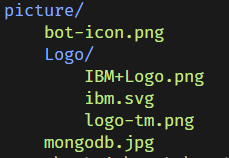


In [ ]:
from colorama import Fore, Style
import sys
import pathlib

def print_dir_structure(folder: str, indent: int = 0) -> None:
    """
    Print the directory structure of a given folder.
    :param folder: Path to the folder.
    :param indent: Current indentation level for printing.
    """
    folder_path = pathlib.Path(folder)
    if folder_path.exists() and folder_path.is_dir():
        print(' ' * (indent) + Fore.BLUE + folder_path.name + "/" + Style.RESET_ALL)
        for item in folder_path.iterdir():
            if item.is_dir() and not item.name.startswith('.'):
                print_dir_structure(item, indent + 4)
            else:
                print(' ' * (indent + 4) + Fore.GREEN + item.name + Style.RESET_ALL)
    else:
        print(Fore.RED + "The specified folder does not exist." + Style.RESET_ALL)
    



print_dir_structure("/Users/maksymkryvenko/Documents/education/neoversity/goit-pycore-hw-04/")

# Завдання 4

Напишіть консольного бота помічника, який розпізнаватиме команди, що вводяться з клавіатури, та буде відповідати відповідно до введеної команди.

☝ Бот помічник повинен стати для нас прототипом застосунку-асистента, який ми розробимо в наступних домашніх завданнях. Застосунок-асистент в першому наближенні повинен вміти працювати з книгою контактів та календарем.


У цій домашній роботі зосередимося на інтерфейсі самого бота. Найпростіший і найзручніший на початковому етапі розробки інтерфейс - це консольний застосунок CLI (Command Line Interface). CLI достатньо просто реалізувати.

Будь-який CLI складається з трьох основних елементів:

Парсер команд. Частина, яка відповідає за розбір введених користувачем рядків, виділення з рядка ключових слів та модифікаторів команд.
Функції обробники команд - набір функцій, які ще називають handler, вони відповідають за безпосереднє виконання команд.
Цикл запит-відповідь. Ця частина застосунку відповідає за отримання від користувача даних та повернення користувачеві відповіді від функції - handler-а.


На першому етапі наш бот-асистент повинен вміти зберігати ім'я та номер телефону, знаходити номер телефону за ім'ям, змінювати записаний номер телефону, виводити в консоль всі записи, які зберіг. Щоб реалізувати таку нескладну логіку, скористаємося словником. У словнику будемо зберігати ім'я користувача, як ключ, і номер телефону як значення.



Вимоги до завдання:

Програма повинна мати функцію main(), яка управляє основним циклом обробки команд.
Реалізуйте функцію parse_input(), яка розбиратиме введений користувачем рядок на команду та її аргументи. Команди та аргументи мають бути розпізнані незалежно від регістру введення.
Ваша програма повинна очікувати на введення команд користувачем та обробляти їх за допомогою відповідних функцій. В разі введення команди "exit" або "close", програма повинна завершувати виконання.
Напишіть функції обробники для різних команд, такі як add_contact(), change_contact(), show_phone() тощо.
Використовуйте словник Python для зберігання імен і номерів телефонів. Ім'я буде ключем, а номер телефону – значенням.
Ваша програма має вміти ідентифікувати та повідомляти про неправильно введені команди.


Рекомендації для виконання

По перше, нам треба систематизувати опис форматів наших команд для консольного бота-помічника. Це допоможе зрозуміти які функції треба зробити для кожної команди. Зробімо це:

1. Команда "hello", тут можна обійтись поки без функції та використати звичайний print:

Введення: "hello"
Вивід: "How can I help you?"


2. Команда "add [ім'я] [номер телефону]". Для цієї команди зробимо функцію add_contact:

Введення: "add John 1234567890"
Вивід: "Contact added."


3. Команда "change [ім'я] [новий номер телефону]". Для цієї команди зробимо функцію change_contact:

Введення: "change John 0987654321"
Вивід: "Contact updated." або повідомлення про помилку, якщо ім'я не знайдено


4. Команда "phone [ім'я]". Для цієї команди зробимо функцію show_phone:

Введення: "phone John"
Вивід: [номер телефону] або повідомлення про помилку, якщо ім'я не знайдено


5. Команда "all". Для цієї команди зробимо функцію show_all:

Введення: "all"
Вивід: усі збережені контакти з номерами телефонів


6. Команда "close" або "exit". Оскільки тут треба перервати виконання програми, можна поки обійтись без функції для цих команд:

Введення: будь-яке з цих слів
Вивід: "Good bye!" та завершення роботи бота
Будь-яка команда, яка не відповідає вищезазначеним форматам, буде вважатися нами невірною, і бот буде виводити повідомлення "Invalid command."



Почнемо з простого варіанту CLI-бота:

def main():
    print("Welcome to the assistant bot!")
    while True:
        command = input("Enter a command: ").strip().lower()

        if command in ["close", "exit"]:
            print("Good bye!")
            break

        elif command == "hello":
            print("How can I help you?")
        else:
            print("Invalid command.")

if __name__ == "__main__":
    main()



Коли програма запускається, вона виводить повідомлення "Welcome to the assistant bot!" і входить в нескінчений цикл, де вона очікує введення команди від користувача while True.



Якщо користувач вводить "close" або "exit", програма виводить "Good bye!" та завершує роботу. За це відповідає блок коду:

if command in ["close", "exit"]:
    print("Good bye!")
    break



Якщо користувач вводить "hello", програма виводить "How can I help you?". Якщо ж введена команда не відповідає жодному з цих варіантів, програма виводить "Invalid command.".

Welcome to the assistant bot!
Enter a command: test
Invalid command.
Enter a command: hello
How can I help you?
Enter a command: exit
Good bye!



Цей код створює простий інтерактивний командний рядок, який реагує на обмежений набір команд. Ми реалізували цикл запит-відповідь, який буде служити відмінною основою для додавання функціональності в майбутніх домашніх завданнях.



Тепер додамо парсер команд. Перепишемо наш код наступним чином

def parse_input(user_input):
    cmd, *args = user_input.split()
    cmd = cmd.strip().lower()
    return cmd, *args

def main():
    print("Welcome to the assistant bot!")
    while True:
        user_input = input("Enter a command: ")
        command, *args = parse_input(user_input)

        if command in ["close", "exit"]:
            print("Good bye!")
            break

        elif command == "hello":
            print("How can I help you?")
        else:
            print("Invalid command.")

if __name__ == "__main__":
    main()



Ми додали функцію parse_input(user_input) яка приймає рядок вводу користувача user_input і розбиває його на слова за допомогою методу split(). Вона повертає перше слово як команду cmd та решту як список аргументів *args. Рядок коду cmd, *args = user_input.split() розділяє рядок на слова. Перше слово зберігається у змінній cmd, а решта зберігається у списку args завдяки оператору розпакування *. Далі рядок коду cmd = cmd.strip().lower() видаляє зайві пробіли навколо команди та перетворює її на нижній регістр.



☝ Навіщо приводити команду до нижнього регістру?

Припустимо, користувач вводить команду як "HELLO", "Hello" або "hello". Якщо не привести ці варіанти до спільного регістру, вони будуть розглядатися як різні команди, і вам доведеться обробляти кожний варіант окремо.

Приведення команди до нижнього регістру дозволяє уникнути цього, перетворюючи всі варіанти на одну та ту ж форму. Таким чином, ви можете легко порівнювати введену команду з попередньо визначеними командами без зважання на те, як користувач ввів її.
Це забезпечує кращий досвід користувача, оскільки програма стає менш чутливою до конкретного способу введення команд.


Отриманий результат в функції main ми отримаємо після виконання рядка коду command, *args = parse_input(user_input) .



Функція parse_input розбиває введений рядок на слова, використовуючи пробіл як розділювач. Змінна command отримує перше значення та вважається командою, а змінна args стає списком з усіх інших значень.



Наприклад, якщо ми введемо команду "add John 123456" то змінна command стане рядком "add" а змінна args стане списком ["John", "123456"] . Якщо ж ми введемо команду "hello" то command стане рядком "hello", а args буде пустим списком []



Маємо надію, ви вже зрозуміли тепер принцип парсера, настав час додати команду add.

def parse_input(user_input):
    cmd, *args = user_input.split()
    cmd = cmd.strip().lower()
    return cmd, *args

def add_contact(args, contacts):
    name, phone = args
    contacts[name] = phone
    return "Contact added."

def main():
    contacts = {}
    print("Welcome to the assistant bot!")
    while True:
        user_input = input("Enter a command: ")
        command, *args = parse_input(user_input)

        if command in ["close", "exit"]:
            print("Good bye!")
            break
        elif command == "hello":
            print("How can I help you?")
        elif command == "add":
            print(add_contact(args, contacts))
        else:
            print("Invalid command.")

if __name__ == "__main__":
    main()



Ми додали словник з контактами contacts = {} в середину функції main та функцію обробник команди add_contact.



Функція add_contact призначена для додавання нового контакту до словника контактів. Вона приймає два аргументи: args, який є списком і містить ім'я та телефонний номер, та contacts, який є словником, де зберігаються контакти.



Всередині функції, два елементи зі списку args розпаковуються в змінні name та phone. Функція далі додає пару "ключ: значення" до словника контактів, використовуючи ім'я як ключ і телефонний номер як значення contacts[name] = phone.

☝ Треба зауважити, що, якщо контакт з таким ім'ям вже існує, його дані будуть перезаписані без будь-яких попереджень. Тут ви вже можете діяти на свій розсуд, хочете чи ні ви обробляти колізію, в нашому варіанті ми перезаписуємо контакт.


Функція add_contact повертає рядок, що підтверджує успішне додавання контакту: "Contact added.".



Необхідно зауважити, що ця функція не має вбудованих перевірок на помилки введення. Наприклад, якщо args не містить двох елементів, ця функція викличе помилку ValueError.

ValueError: not enough values to unpack (expected 2, got 0)



Обробку помилок в цьому домашньому завданні залиште на свій розсуд, бо в наступному домашньому завданні ми додамо обробку помилок через декоратори.



Критерії оцінювання:

Бот повинен перебувати в нескінченному циклі, чекаючи команди користувача.
Бот завершує свою роботу, якщо зустрічає слова: "close" або "exit".
Бот не чутливий до регістру введених команд.
Бот приймає команди:
"hello", та відповідає у консоль повідомленням "How can I help you?"
"add username phone". За цією командою бот зберігає у пам'яті, наприклад у словнику, новий контакт. Користувач вводить ім'я username та номер телефону phone, обов'язково через пробіл.
"change username phone". За цією командою бот зберігає в пам'яті новий номер телефону phone для контакту username, що вже існує в записнику.
"phone username" За цією командою бот виводить у консоль номер телефону для зазначеного контакту username.
"all". За цією командою бот виводить всі збереженні контакти з номерами телефонів у консоль.
"close", "exit" за будь-якою з цих команд бот завершує свою роботу після того, як виведе у консоль повідомлення "Good bye!" та завершить своє виконання.
Логіка команд реалізована в окремих функціях і ці функції приймають на вхід один або декілька рядків та повертають рядок.
Вся логіка взаємодії з користувачем реалізована у функції main, всі print та input відбуваються тільки там.

In [ ]:
class ContactBook:
    """
    A simple contact book to save, get, update, and show contacts.
    """
    def __init__(self):
        self.contacts = {}

    def save_contact(self, name: str, phone: str):
        """
        Save name and phone number.
        """
        self.contacts[name] = phone
        print("Contact saved.")

    def get_contact(self, name: str):
        """
        Get phone number by name.
        """
        print(self.contacts.get(name, "Contact not found."))

    def update_contact(self, name: str, phone: str):
        """
        Update phone number for existing contact.
        """
        if name in self.contacts:
            self.contacts[name] = phone
            print("Contact updated.")
        else:
            print("Contact not found.")

    def show_all_contacts(self):
        """
        Show all saved contacts.
        """
        for name, phone in self.contacts.items():
            print(f"Name: {name}, Phone: {phone}")

def parse_input(string: str):
    """
    Parse user input and return command and arguments.
    """
    parts = string.split(" ")
    if len(parts) == 1:
        return parts[0].lower(), []
    elif len(parts[0]) > 1:
        return parts[0].lower(), parts[1:]
    else:  
        return None, []

def main():
    """
    Main function to run the contact book bot.
    """
    contact_book = ContactBook()
    print("Welcome to the Contact Book Bot!")
    print("""Available functions and commands: 
          * save <name> <phone> - Save a new contact
          * get <name> - Get a contact's phone number
          * change/update <name> <phone> - Update an existing contact
          * show all - Show all contacts
          * close/exit - Exit the bot
          """)
    while True:
        user_input = input("Enter command: ")
        command, *args = parse_input(user_input)

        if command in ["add", "save"]:
            if len(args[0]) == 2:
                contact_book.save_contact(*args[0])
            else:
                print("Please provide a name and phone number to save the contact.")
        elif command in ["change", "update"]:
            if len(args[0]) == 2:
                contact_book.update_contact(*args[0])
            else:
                print("Please provide a name and phone number to update the contact.")
        elif command in ["show", "phone"]:
            if args[0]:
                contact_book.get_contact(*args[0])
            else:
                print("Please provide a name to get the contact.")
        elif command in ["show all", "all"]:
            contact_book.show_all_contacts()
        elif command in ["exit", "close", "good bye"]:
            print("Good bye!")
            break
        elif command == "hello":
            print("How can I help you?")
        else:
            print("Unknown command. Please try again.")

main()